In [1]:
import os, re
import numpy as np

# plotting styles
import matplotlib as mpl
from matplotlib import pyplot as plt

%matplotlib inline

mpl.rcParams['figure.dpi']= 150

In [2]:
import h5py

with h5py.File("../data/dr12q/processed/subdla_samples.mat", "r") as f:
    print(f.keys())
    # <KeysViewHDF5 ['Z_dla', 'Z_lls', 'alpha', 'extrapolate_min_log_nhi', 'fit_max_log_nhi', 'fit_min_log_nhi', 'lls_log_nhi_samples', 'lls_nhi_samples', 'num_dla_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
    Z_dla = f["Z_dla"][0, 0]
    Z_lls = f["Z_lls"][0, 0]
    alpha = f["alpha"][0, 0]
    fit_min_log_nhi = f["fit_min_log_nhi"][0, 0]
    fit_max_log_nhi = f["fit_max_log_nhi"][0, 0]
    extrapolate_min_log_nhi = f["extrapolate_min_log_nhi"][0, 0]
    lls_log_nhi_samples = f["lls_log_nhi_samples"][:]
    lls_nhi_samples = f["lls_nhi_samples"][:]
    num_dla_samples = f["num_dla_samples"][:]
    offset_samples = f["offset_samples"][:]
    uniform_min_log_nhi = f["uniform_min_log_nhi"][0, 0]
    uniform_max_log_nhi = f["uniform_max_log_nhi"][0, 0]


<KeysViewHDF5 ['Z_dla', 'Z_lls', 'alpha', 'extrapolate_min_log_nhi', 'fit_max_log_nhi', 'fit_min_log_nhi', 'lls_log_nhi_samples', 'lls_nhi_samples', 'num_dla_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>


In [3]:
Z_dla, Z_lls, alpha, fit_min_log_nhi, fit_max_log_nhi, extrapolate_min_log_nhi, uniform_min_log_nhi, uniform_max_log_nhi

(0.6280093524954454, 0.3719892435474267, 0.97, 20.0, 22.0, 19.5, 19.5, 23.0)

Sum of the PDF:


1.0010173454007558

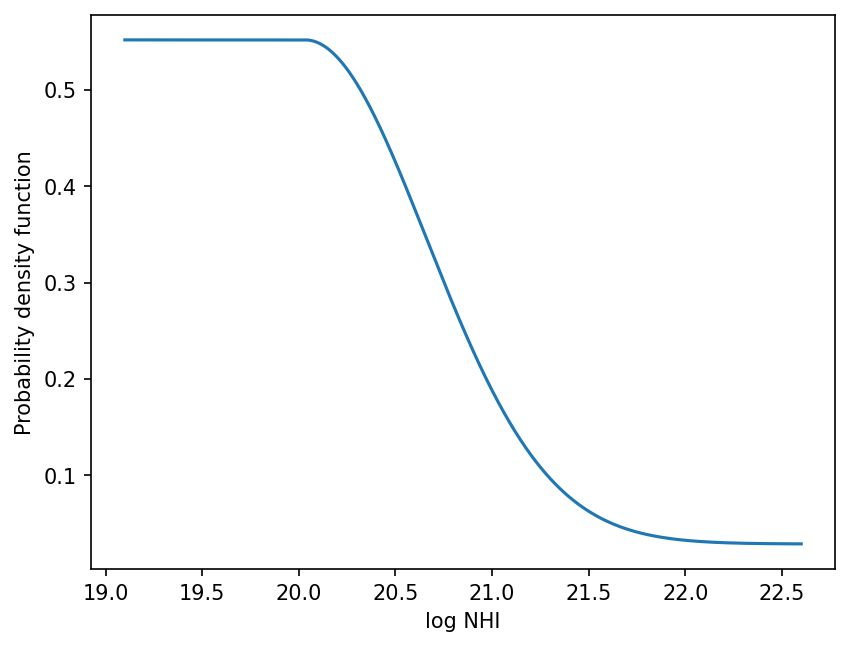

In [4]:
from scipy.integrate import quad # to get the normalization constant for the probability density function

# normalization factor a for uniform prior
a = 0.90
uniform_min_log_nhi = 19.1
uniform_max_log_nhi = 22.6

# directly use the fitted poly values in the Garnett (2017)
unnormalized_dla_pdf = lambda log_nhi: (np.exp(
    -1.2695 * log_nhi**2 + 50.863 * log_nhi -509.33
    )
)
# add a flat prior at the low column density end
unnormalized_pdf = lambda log_nhi : (
    unnormalized_dla_pdf(log_nhi) * (log_nhi >= 20.03) +
    unnormalized_dla_pdf(20.03)      * (log_nhi <  20.03)
)

Z = quad(unnormalized_pdf, uniform_min_log_nhi, uniform_max_log_nhi)[0]

# # % uniform component of column density prior
# u = makedist('uniform', ...
#              'lower', uniform_min_log_nhi, ...
#              'upper', uniform_max_log_nhi);
#           alpha  * (unnormalized_pdf(nhi) / Z) + ...
# #  (1 - alpha) * (pdf(u, nhi));
# % normalized PDF with uniform prior
normalized_pdf = lambda log_nhi: (
    a * unnormalized_pdf(log_nhi) / Z 
    + (1 - a) * (log_nhi >= uniform_min_log_nhi) * (log_nhi <= uniform_max_log_nhi) / (uniform_max_log_nhi - uniform_min_log_nhi)
)


log_nhis = np.linspace(uniform_min_log_nhi, uniform_max_log_nhi, num=1000)
plt.plot(log_nhis, normalized_pdf(log_nhis))
plt.xlabel("log NHI")
plt.ylabel("Probability density function")

# Make sure the probability density is summed to one
print("Sum of the PDF:")
np.sum(normalized_pdf(log_nhis) * (log_nhis[1] - log_nhis[0]))

In [5]:
Z_dla, Z_lls

(0.6280093524954454, 0.3719892435474267)

In [6]:
xgrid = np.linspace(19.1, 22.6, 1000)
dx = xgrid[1] - xgrid[0]
integral = normalized_pdf(xgrid).sum() * dx
print(integral)  # should be very close to 1

# only for dla: 20-22.6
xgrid_dla = np.linspace(20.0, 22.6, 1000)
dx_dla = xgrid_dla[1] - xgrid_dla[0]
integral_dla = normalized_pdf(xgrid_dla).sum() * dx_dla
print(integral_dla)  # should be very close to 1

# only for subdla: 19.1-20.0
xgrid_subdla = np.linspace(19.1, 20.0, 1000)
dx_subdla = xgrid_subdla[1] - xgrid_subdla[0]
integral_subdla = normalized_pdf(xgrid_subdla).sum() * dx_subdla
print(integral_subdla)  # should be very close to 1

1.0010173454007558
0.5038968932340979
0.497356205213702


In [7]:
# We want Monte Carlo samples - here to use Halton sequence to speed up the convergence
from scipy.stats.qmc import Halton
from scipy.interpolate import interp1d

sampler = Halton(
    d=4, # dimension of parameter space
    scramble=True,
)



In [8]:
np.random.seed(42)  # for reproducibility

num_samples = 100000
halton_sequence = sampler.random(num_samples)

# Inver transform sampling
# https://en.wikipedia.org/wiki/Inverse_transform_sampling
# code ref:
# https://gist.github.com/amarvutha/c2a3ea9d42d238551c694480019a6ce1
def sample(g, min_lognhi = 19.1, max_lognhi = 20.0):
    x = np.linspace(
        min_lognhi,
        max_lognhi,
        num=int(1e8),               # if you see interpolation error, increase this number 
    )
    y = g(x)                        # probability density function, pdf
    cdf_y = np.cumsum(y)            # cumulative distribution function, cdf
    cdf_y = cdf_y/cdf_y.max()       # takes care of normalizing cdf to 1.0
    inverse_cdf = interp1d(cdf_y, x)    # this is a function
    return inverse_cdf

def return_samples(halton_sequence: np.ndarray):
    required_samples = sample(
        normalized_pdf
    )(halton_sequence)
    return required_samples

samples_log_nhis = return_samples(halton_sequence[:, 2], )

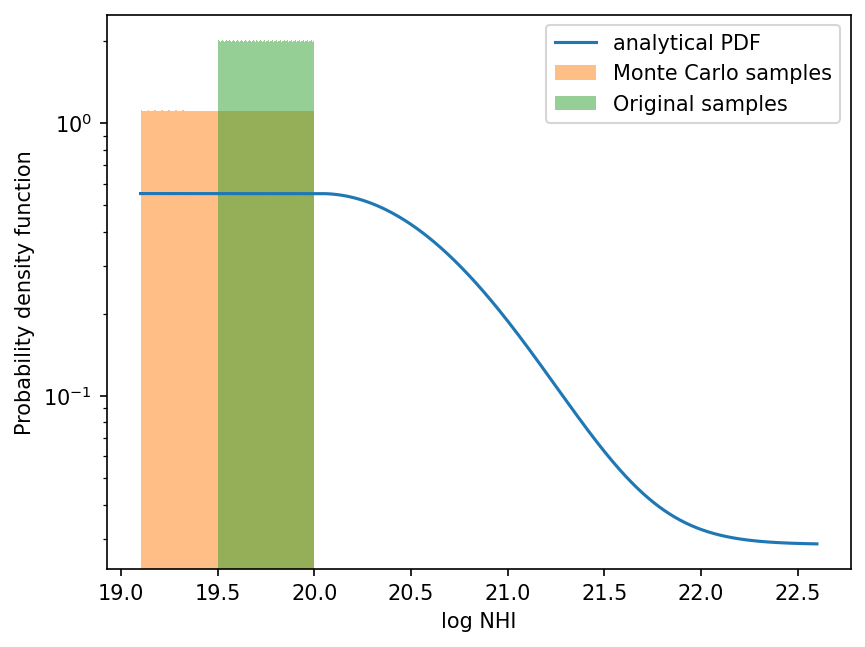

In [9]:
plt.plot(log_nhis, normalized_pdf(log_nhis), label="analytical PDF")
plt.xlabel("log NHI")
plt.ylabel("Probability density function")
plt.hist(samples_log_nhis, bins=100, density=True, alpha=0.5, label="Monte Carlo samples")
plt.hist(lls_log_nhi_samples, bins=100, density=True, alpha=0.5, label="Original samples")

# yscale log
plt.yscale("log")
plt.legend()

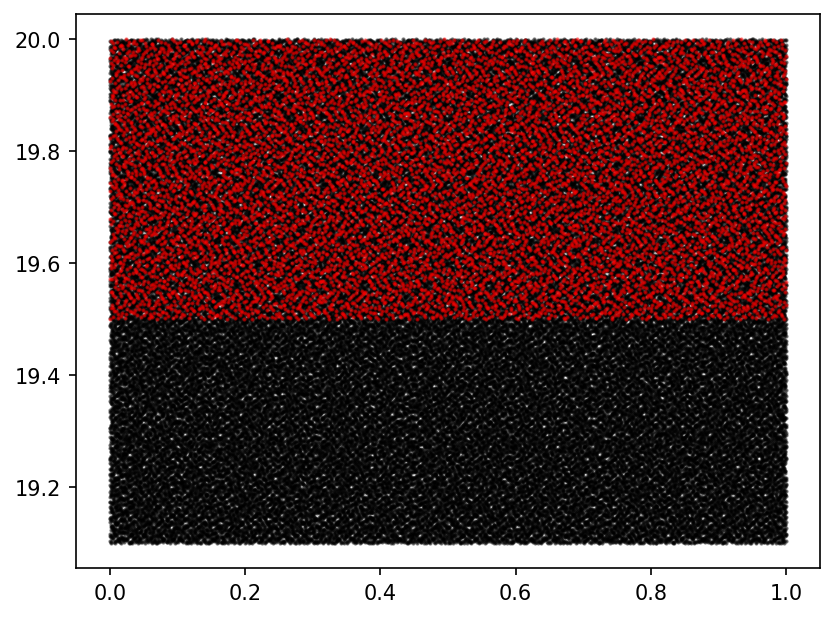

In [10]:
# visualize halton sequence
plt.scatter(
    halton_sequence[:, 3], samples_log_nhis[:], 
    s=1, alpha=0.5, c="black"
)
# original
plt.scatter(
    offset_samples, lls_log_nhi_samples, 
    s=1, alpha=0.5, c="red"
)

Save the samples

In [11]:
# Single model: 19.9 - 22.6
import h5py

with h5py.File("../data/dr12q/processed/subdla_samples_a10_191_200_100000.mat", "w") as f:
    print(f.keys())
    # <KeysViewHDF5 ['Z_dla', 'Z_lls', 'alpha', 'extrapolate_min_log_nhi', 'fit_max_log_nhi', 'fit_min_log_nhi', 'lls_log_nhi_samples', 'lls_nhi_samples', 'num_dla_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
    # log_nhi_samples.shape: (10000, 1)
    # alpha.shape: (1, 1)
    # offset_samples.shape: (10000, 1)
    # fit_min_log_nhi.shape: (1, 1)
    # fit_max_log_nhi.shape: (1, 1)
    # uniform_min_log_nhi.shape: (1, 1) 
    f.create_dataset("Z_dla", data=np.array([integral_dla])[:, None])
    f.create_dataset("Z_lls", data=np.array([integral_subdla])[:, None])
    f.create_dataset("alpha", data=np.array([a])[:, None])
    f.create_dataset("extrapolate_min_log_nhi", data=np.array([uniform_min_log_nhi])[:, None])
    f.create_dataset("fit_max_log_nhi", data=np.array([fit_max_log_nhi])[:, None])
    f.create_dataset("fit_min_log_nhi", data=np.array([fit_min_log_nhi])[:, None])
    f.create_dataset("lls_log_nhi_samples", data=samples_log_nhis[:, None])
    f.create_dataset("num_dla_samples", data=np.array([num_dla_samples])[:, None])
    f.create_dataset("offset_samples", data=halton_sequence[:, 3][:, None])
    f.create_dataset("uniform_min_log_nhi", data=np.array([uniform_min_log_nhi])[:, None])
    f.create_dataset("uniform_max_log_nhi", data=np.array([uniform_max_log_nhi])[:, None])
    f.create_dataset("lls_nhi_samples", data=10**samples_log_nhis[:, None])
    print("Saved samples to ../data/dr12q/processed/subdla_samples_a10_191_200_100000.mat")

# double check the shape of the samples
with h5py.File("../data/dr12q/processed/subdla_samples_a10_191_200_100000.mat", "r") as f:
    log_nhi_samples = f["lls_log_nhi_samples"][:]
    print("log_nhi_samples.shape:", log_nhi_samples.shape)
    assert log_nhi_samples.shape == (100000, 1)
    print("Samples shape is correct.")

    # other variables
    print("alpha.shape:", f["alpha"][:].shape)
    print("offset_samples.shape:", f["offset_samples"][:].shape)
    print("fit_min_log_nhi.shape:", f["fit_min_log_nhi"][:].shape)
    print("fit_max_log_nhi.shape:", f["fit_max_log_nhi"][:].shape)
    print("uniform_min_log_nhi.shape:", f["uniform_min_log_nhi"][:].shape)
    print("uniform_max_log_nhi.shape:", f["uniform_max_log_nhi"][:].shape)
    print("nhi_samples.shape:", f["lls_nhi_samples"][:].shape)
    assert f["lls_nhi_samples"][:].shape == (100000, 1)
    print("All shapes are correct.")


<KeysViewHDF5 []>
Saved samples to ../data/dr12q/processed/subdla_samples_a10_191_200_100000.mat
log_nhi_samples.shape: (100000, 1)
Samples shape is correct.
alpha.shape: (1, 1)
offset_samples.shape: (100000, 1)
fit_min_log_nhi.shape: (1, 1)
fit_max_log_nhi.shape: (1, 1)
uniform_min_log_nhi.shape: (1, 1)
uniform_max_log_nhi.shape: (1, 1)
nhi_samples.shape: (100000, 1)
All shapes are correct.
